### Atomic Level GNN construction for the prediction of amino acid properties

Here we read all properties with RMSE, I rank these preperties based their RMSE and RJN values, as we want to find a property with smaller RMSE and greatest RJN to train the GNN.  

 1) RMSE: how close predictions were numerically according to the paper
 2) RJN: the pearson correlation coefficient, how predicatable a property is from the atomic structure of the amino acid also according to the paper 

In [1]:
import numpy as np
import os
import pandas as pd
import torch
from torch_geometric.data import InMemoryDataset
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from torch_geometric.data import Data
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

/Users/joshuahoang/anaconda3/envs/phys188/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = np.genfromtxt(
    'data/aaindexnc/ncAAs/0AF.predicted',
    dtype=None, 
    encoding='utf-8', 
    names=True,
      skip_header=1
      )
sorted_data = np.sort(data, order='RMSE')

sorted_data_df = pd.DataFrame(sorted_data)
display(sorted_data_df)

,Property,Value,rjn,RMSE,Predictors,Fvalue
0,CHAM820101,0.421365,0.9990,0.00452,10,1.2
1,JOND920101,0.015050,0.7970,0.01380,6,1.3
2,VINM940104,0.817641,0.2880,0.02470,10,1.1
3,VINM940103,0.930353,0.7350,0.02600,4,2.9
4,PRAM820102,0.092006,0.7100,0.03710,6,1.3
...,...,...,...,...,...,...
559,NADH010104,29.659900,0.5130,109.00000,10,1.0
560,NADH010106,56.118100,0.3440,113.00000,9,1.3
561,BIOV880102,64.386400,0.5470,120.00000,10,1.0
562,NADH010107,34.833300,-0.0531,138.00000,1,2.6


In [3]:
# Thresholds for "good" atomic targets
rmse_max = 0.1
rjn_min  = 0.7 

mask_good = (sorted_data_df["RMSE"] < rmse_max) & (sorted_data_df["rjn"] > rjn_min)
good_features_df = sorted_data_df[mask_good].copy()

print("Selected features:")
display(good_features_df[["Property", "rjn", "RMSE"]])

# Store these good features into chem_attr to be used in the atomic level gnn 
good_features = np.array(good_features_df)
chem_attr = []

for row in good_features:
    # print(row[0])
    chem_attr.append(row[0])

print(chem_attr)

Selected features:


,Property,rjn,RMSE
0,CHAM820101,0.999,0.00452
1,JOND920101,0.797,0.01380
3,VINM940103,0.735,0.02600
4,PRAM820102,0.710,0.03710
6,OOBM770102,0.940,0.04230
7,COHE430101,0.887,0.04530
9,LEVM760107,0.938,0.04650
10,BULH740102,0.842,0.05130
20,WEBA780101,0.926,0.06910
21,LEVM760105,0.989,0.06990


['CHAM820101', 'JOND920101', 'VINM940103', 'PRAM820102', 'OOBM770102', 'COHE430101', 'LEVM760107', 'BULH740102', 'WEBA780101', 'LEVM760105', 'ZASB820101', 'KUHL950101']


Loading and reading the data.

In [4]:
def read_ncaa_values(filename):
    """ Read a single NCAA file and return a DataFrame with Property and Value."""
    data = []
    try:
        with open(filename, 'r') as f:
            lines = f.readlines()
    except FileNotFoundError:
        print(f"File not found: {filename}")
        return pd.DataFrame()

    if len(lines) < 3:
        return pd.DataFrame()
    
    # Line 0: ncAA_ID, SMILES, Name (tab-separated)
    header_parts = lines[0].strip().split('\t')
    if len(header_parts) < 3:
        print(f"Invalid header in {filename}")
        return pd.DataFrame()
    
    ncaa_id = header_parts[0]
    smiles = header_parts[1]
    name = header_parts[2] if len(header_parts) > 2 else ""
    
    # Line 1 is column headers: Property, Value, rjn, RMSE, Predictors, Fvalue
    # Lines 2+: Property data (tab-separated)
    for i in range(2, len(lines)):
        line = lines[i].strip()
        if line == '':
            continue
        
        cols = line.split('\t')
        if len(cols) >= 2:
            try:
                property_name = cols[0]
                value = float(cols[1])
                data.append({
                    'ncAA_ID': ncaa_id,
                    'Name': name,
                    'SMILES': smiles,
                    'Property': property_name,
                    'Value': value
                })
            except (ValueError, IndexError) as e:
                print(f"Skipping invalid line in {filename}: {line}")
                continue

    df = pd.DataFrame(data)
    return df

def read_all_ncaa_values(folder_path):
    """Read all NCAA files and create a 2D DataFrame of Values only."""
    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_path}")
        return None
    
    all_files = [f for f in os.listdir(folder_path) if f.endswith('.predicted')]
    print(f"Found {len(all_files)} .predicted files in {folder_path}")
    
    if len(all_files) == 0:
        print("No .predicted files found!")
        return None
    
    df_list = []

    for i, f in enumerate(all_files):
        df = read_ncaa_values(os.path.join(folder_path, f))
        if not df.empty:
            df_list.append(df)
        else:
            print(f"✗ Empty result from {f}")

    if len(df_list) == 0:
        print("No data was loaded from any files.")
        return None
    
    print(f"\nSuccessfully loaded {len(df_list)} files.")
    combined_df = pd.concat(df_list, ignore_index=True)
    print(f"Combined data shape: {combined_df.shape}")

    # Pivot to wide format: rows=ncAA, columns=Property, values=Value
    df_wide = combined_df.pivot_table(
        index=['ncAA_ID','Name','SMILES'],
        columns='Property',
        values='Value'
        ).reset_index()
    return df_wide

# Load the data from Folder path
folder_path = "data/aaindexnc/ncAAs"
print(f"Checking folder: {folder_path}")
print(f"Folder exists: {os.path.exists(folder_path)}\n")

df_values = read_all_ncaa_values(folder_path)
if df_values is not None:
    print(f"\nFinal shape: {df_values.shape}")
    print(f"Columns: {df_values.columns.tolist()[:10]}")  # First 10 property columns
else:
    print("Failed to load data.")

df_mask = True

for attr in chem_attr:
    df_x = df_values[attr].notna() & (df_values[attr] != 0)
    df_mask &= df_x

df_polar = df_values[df_mask]

display(df_polar)

Checking folder: data/aaindexnc/ncAAs
Folder exists: True

Found 558 .predicted files in data/aaindexnc/ncAAs

Successfully loaded 558 files.
Combined data shape: (314712, 5)

Final shape: (558, 567)
Columns: ['ncAA_ID', 'Name', 'SMILES', 'ANDN920101', 'ARGP820101', 'ARGP820102', 'ARGP820103', 'AURR980101', 'AURR980102', 'AURR980103']


Property,ncAA_ID,Name,SMILES,ANDN920101,ARGP820101,ARGP820102,ARGP820103,AURR980101,AURR980102,AURR980103,...,YUTK870104,ZASB820101,ZHOH040101,ZHOH040102,ZHOH040103,ZIMJ680101,ZIMJ680102,ZIMJ680103,ZIMJ680104,ZIMJ680105
0,02K,1-AMINOCYCLOHEXANECARBOXYLIC ACID,NC1(CCCCC1)C(O)=O,4.07400,2.722410,1.914640,2.087760,1.025,1.226980,1.072730,...,19.15370,-0.105445,2.90033,4.39504,9.76043,3.857640,20.5712,-2.53793,6.187440,20.93880
1,02Y,6-DIAZONIO-5-OXO-L-NORLEUCINE,N[C@@H](CCC(=O)C[N+]#N)C(O)=O,4.71677,-0.034334,-0.296034,-0.522679,1.025,1.027740,1.010570,...,18.06680,-0.225555,1.61677,3.73668,3.27818,0.635693,13.6997,69.02500,9.333830,-1.22862
2,03Y,2-METHYL-L-CYSTEINE,C[C@](N)(CS)C(O)=O,4.58500,0.982912,2.280000,2.095000,0.740,0.765001,0.794999,...,18.16500,-0.105445,3.76000,2.41996,19.15000,1.234550,14.6584,-2.53793,5.395000,8.85000
3,05N,"(3R,4R)-4-HYDROXY-3-METHYL-L-PROLINE",C[C@H]1[C@@H](O)CN[C@@H]1C(O)=O,4.34141,1.329580,1.046900,1.459710,1.025,0.629246,0.836969,...,18.34320,-0.225555,3.98782,3.73668,18.15230,2.392200,24.8469,15.45370,5.835460,15.53700
4,07O,S-[(2S)-2-PHENYLPROPANOYL]-L-CYSTEINE,C[C@H](C(=O)SC[C@H](N)C(O)=O)c1ccccc1,5.34912,2.895740,1.984820,1.497950,0.740,0.565756,0.793171,...,18.41620,-0.004101,7.97498,6.61597,30.87140,3.459020,29.7740,15.45370,2.883410,16.22980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
553,YPZ,3-[(3Z)-4-HYDROXY-6-OXO-3-(2-PHENYLHYDRAZINYLI...,N[C@@H](CC1=C/C(=N/Nc2ccccc2)C(=CC1=O)O)C(O)=O,4.47743,4.242440,0.942574,1.084960,1.025,1.027740,0.914274,...,-1.94940,-0.124211,5.59438,8.59105,11.26270,-4.155290,31.6089,33.44540,-0.477882,-5.69201
554,Z3E,O-BENZYL-L-THREONINE,C[C@@H](OCc1ccccc1)[C@H](N)C(O)=O,4.61889,2.509540,0.856041,1.237410,1.025,0.828491,0.953938,...,18.18930,-0.004101,6.56806,5.95762,25.13670,4.010590,26.8068,15.45370,5.757850,21.90640
555,ZYJ,"(4R)-4-({[(1E)-(3,4-DIMETHOXYPHENYL)METHYLIDEN...",COc1ccc(/C=N/O[C@H]2CN[C@@H](C2)C(O)=O)cc1OC,4.33505,3.568850,0.074832,1.092800,1.025,0.828491,1.048330,...,-2.45378,-0.244321,5.60259,7.93269,13.67660,1.636860,31.0845,51.43700,4.201320,13.63120
556,ZYK,"(4R)-4-({[(3,4-DIMETHOXYPHENYL)CARBONYL]AMINO}...",COc1ccc(cc1OC)C(=O)NO[C@H]2CN[C@@H](C2)C(O)=O,4.74987,2.252560,-0.602055,0.051161,1.025,0.828491,1.163470,...,15.17480,-0.364431,4.77612,7.93269,8.84523,1.636860,29.3612,69.42860,4.921290,11.31230


In [5]:
print(f"Number of ncAAs with all the needed attr:", len(df_polar))
display(df_polar[['ncAA_ID','Name','SMILES', chem_attr[0], chem_attr[1], chem_attr[2]]].head())

Number of ncAAs with all the needed attr: 558


Property,ncAA_ID,Name,SMILES,CHAM820101,JOND920101,VINM940103
0,02K,1-AMINOCYCLOHEXANECARBOXYLIC ACID,NC1(CCCCC1)C(O)=O,0.223631,0.061970,1.047450
1,02Y,6-DIAZONIO-5-OXO-L-NORLEUCINE,N[C@@H](CCC(=O)C[N+]#N)C(O)=O,0.258935,0.049800,1.032600
2,03Y,2-METHYL-L-CYSTEINE,C[C@](N)(CS)C(O)=O,0.174497,0.022000,0.950999
3,05N,"(3R,4R)-4-HYDROXY-3-METHYL-L-PROLINE",C[C@H]1[C@@H](O)CN[C@@H]1C(O)=O,0.199829,0.048620,0.998131
4,07O,S-[(2S)-2-PHENYLPROPANOYL]-L-CYSTEINE,C[C@H](C(=O)SC[C@H](N)C(O)=O)c1ccccc1,0.505800,-0.043102,0.946962


I need to clean the data in case there are some outliers: for example, some of the amino acid conatin heavy metal ions, and it may be badly predicted. Below I am printing the top 10 heaviest atom in amino acid molecule:

In [6]:
# clean data
def get_heaviest_atom(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None, None
        atoms = mol.GetAtoms()
        masses = [(atom.GetSymbol(), atom.GetMass()) for atom in atoms]
        return max(masses, key=lambda x: x[1])
    except:
        return None, None
    
df_values['HeaviestAtom'] = df_values['SMILES'].apply(get_heaviest_atom)
# Remove rows where calculation failed
df_values['HeaviestAtomInfo'] = df_values['SMILES'].apply(get_heaviest_atom)
df_values['HeaviestAtomSymbol'] = df_values['HeaviestAtomInfo'].apply(lambda x: x[0])
df_values['HeaviestAtomMass']   = df_values['HeaviestAtomInfo'].apply(lambda x: x[1])

df_valid = df_values[df_values['HeaviestAtomMass'].notna()]

# identify 4 heaviest ncAAs
df_sorted = df_valid.sort_values(by='HeaviestAtomMass', ascending=False)
top10_rows = df_sorted.head(10)
top10_ids = top10_rows['ncAA_ID'].tolist()
print("Top 10 ncAAs by heaviest atom:")
for _, row in top10_rows.iterrows():
    print(f"{row['ncAA_ID']}: {row['HeaviestAtomSymbol']} ({row['HeaviestAtomMass']:.2f} amu)")

Top 10 ncAAs by heaviest atom:
31Q: Hg (200.59 amu)
CMH: Hg (200.59 amu)
C4R: Rh (102.91 amu)
SVA: V (50.94 amu)
KOR: S (32.07 amu)
BPE: S (32.07 amu)
BCX: S (32.07 amu)
QYX: S (32.07 amu)
BG1: S (32.07 amu)
EYG: S (32.07 amu)


So we can see there are four molecules containing heavy metal atoms, and I am going to delete them from our amino acid data set.

In [7]:
top4_rows = df_sorted.head(4)
top4_ids = top4_rows['ncAA_ID'].tolist()
print("Top 4 ncAAs by heaviest atom that will be deleted:")
for _, row in top4_rows.iterrows():
    print(f"{row['ncAA_ID']}: {row['HeaviestAtomSymbol']} ({row['HeaviestAtomMass']:.2f} amu)")

df_polar = df_polar[(~df_polar['ncAA_ID'].isin(top4_ids))]

display(df_polar[['ncAA_ID','Name','SMILES',chem_attr[0], chem_attr[1], chem_attr[2]]].head())

id_list = df_polar['ncAA_ID'].tolist()

Top 4 ncAAs by heaviest atom that will be deleted:
31Q: Hg (200.59 amu)
CMH: Hg (200.59 amu)
C4R: Rh (102.91 amu)
SVA: V (50.94 amu)


Property,ncAA_ID,Name,SMILES,CHAM820101,JOND920101,VINM940103
0,02K,1-AMINOCYCLOHEXANECARBOXYLIC ACID,NC1(CCCCC1)C(O)=O,0.223631,0.061970,1.047450
1,02Y,6-DIAZONIO-5-OXO-L-NORLEUCINE,N[C@@H](CCC(=O)C[N+]#N)C(O)=O,0.258935,0.049800,1.032600
2,03Y,2-METHYL-L-CYSTEINE,C[C@](N)(CS)C(O)=O,0.174497,0.022000,0.950999
3,05N,"(3R,4R)-4-HYDROXY-3-METHYL-L-PROLINE",C[C@H]1[C@@H](O)CN[C@@H]1C(O)=O,0.199829,0.048620,0.998131
4,07O,S-[(2S)-2-PHENYLPROPANOYL]-L-CYSTEINE,C[C@H](C(=O)SC[C@H](N)C(O)=O)c1ccccc1,0.505800,-0.043102,0.946962


Now we have all the data we want at df_polar, on the next we will convert SMILES to graph

#### Step 1: Convert molecule to graph

In [8]:
def smiles_to_graph(smile, y=None, node_ft_dict=None, edge_ft_dict=None, device='cpu'):
    """
    Convert a SMILES string to a PyG Data object representing the molecular graph.
    Returns:
        Data: PyG Data object with x, edge_index, edge_attr, and y.
    """
    mol = Chem.MolFromSmiles(smile)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smile}")
    
    # Node features
    atomic_number = [atom.GetAtomicNum() for atom in mol.GetAtoms()]
    aromaticity = [int(atom.GetIsAromatic()) for atom in mol.GetAtoms()]
    num_bonds = [atom.GetDegree() for atom in mol.GetAtoms()]
    bonded_h = [atom.GetTotalNumHs() for atom in mol.GetAtoms()]
    hybridization = [int(atom.GetHybridization()) for atom in mol.GetAtoms()]
    implicit_valence = [atom.GetImplicitValence() for atom in mol.GetAtoms()]

    node_keys_features = [
        f"{a}_{ar}_{b}_{h}_{hy}_{iv}"
        for a, ar, b, h, hy, iv in zip(atomic_number, aromaticity, num_bonds, bonded_h,hybridization, implicit_valence) ####implicit_valence，hybridization
    ]
    
    if node_ft_dict is not None:
        nodes_features = torch.tensor(
            np.array([node_ft_dict[x] for x in node_keys_features]),
            dtype=torch.float32, device=device
        )
    else:
        # If no dict, just use raw features
        nodes_features = torch.tensor(
            np.array([atomic_number, aromaticity, num_bonds, bonded_h,hybridization, implicit_valence]).T, ####implicit_valence, hybridization
            dtype=torch.float32, device=device
        )
    
    # Edge features
    edge_index = []
    edge_attrs = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        bond_type = bond.GetBondTypeAsDouble()
        in_ring = int(bond.IsInRing())
        conjugated = int(bond.GetIsConjugated())
        aromatic = int(bond.GetIsAromatic())
        valence_i = bond.GetBeginAtom().GetTotalValence()
        valence_j = bond.GetEndAtom().GetTotalValence()
        
        edge_attr = [bond_type,in_ring, conjugated, aromatic, valence_i, valence_j] 
        
        # Add both directions for undirected graph
        edge_index.append([i, j])
        edge_index.append([j, i])
        edge_attrs.append(edge_attr)
        edge_attrs.append(edge_attr)
    
    edge_index = torch.tensor(edge_index, dtype=torch.long, device=device).t().contiguous()
    edge_attrs = torch.tensor(edge_attrs, dtype=torch.float32, device=device)
    
    # y as target
    if y is not None:
        y = torch.tensor([y], dtype=torch.float32, device=device)
    
    data = Data(
        x=nodes_features,
        edge_index=edge_index,
        edge_attr=edge_attrs,
        y=y
    )
    
    return data

Now we construct the graph dataset for the filtered ncAAs, and normalize the target properties.

In [9]:
data_list = []

for idx, row in df_polar.iterrows():
    y = [row[attr] for attr in chem_attr]
    
    # Skip if first row value is > 1.5 (to filter outliers)
    if y[0] > 1.5:
        continue
    
    smile = row['SMILES']
    try:
        graph = smiles_to_graph(smile, y=y, device='cpu')
        data_list.append(graph)
    except Exception as e:
        print(f"Skipping {row['ncAA_ID']} due to error: {e}")

print(f"Total graphs for training after filtering: {len(data_list)}")

num_data = len(data_list)

print("Before normalization:")
display(data_list[13].y)
y_vals = np.array([d.y for d in data_list])

display(y_vals.reshape(num_data,len(chem_attr)))

Total graphs for training after filtering: 553
Before normalization:


tensor([[ 0.3446, -0.0259,  0.9039, -0.0827, -1.1689,  0.6163,  0.2450,  0.6446,
          0.6711,  2.3737, -0.1054,  0.8065]])

array([[ 0.223631,  0.06197 ,  1.04745 , ...,  1.78541 , -0.105445,
         0.60771 ],
       [ 0.258935,  0.0498  ,  1.0326  , ...,  2.47815 , -0.225555,
         1.75379 ],
       [ 0.174497,  0.022   ,  0.950999, ...,  1.51    , -0.105445,
         0.60771 ],
       ...,
       [ 0.589784,  0.004758,  0.994094, ...,  3.95746 , -0.244321,
         2.00028 ],
       [ 0.60048 ,  0.004758,  0.994094, ...,  4.18646 , -0.364431,
         2.3982  ],
       [ 0.123053,  0.06986 ,  0.998131, ...,  0.9749  ,  0.014665,
         0.408599]], shape=(553, 12), dtype=float32)

Now we want to know how good the node and edge feature we have now, so we analyze the node and edge information correlation separately:

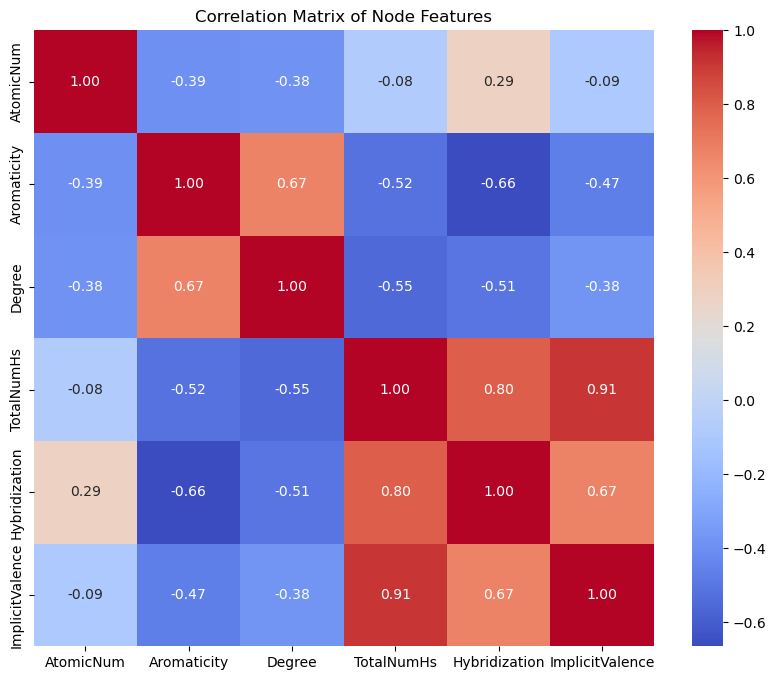

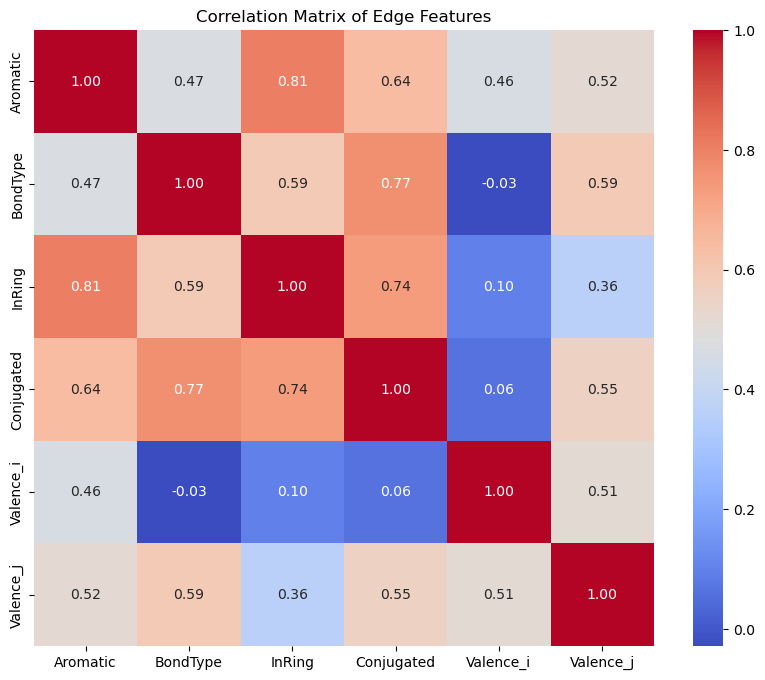

In [10]:
### node and edge information correlation
# data_list contains your PyG Data objects
node_feature_names = ['AtomicNum', 'Aromaticity', 'Degree','TotalNumHs','Hybridization', 'ImplicitValence'] #
mol_node_features = []

for data in data_list:
    x = data.x.numpy()  # shape [num_atoms, num_features]
    # Aggregate per molecule (mean)
    agg_features = x.mean(axis=0)
    mol_node_features.append(agg_features)

df_nodes = pd.DataFrame(mol_node_features, columns=node_feature_names)
corr_matrix = df_nodes.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix of Node Features")
plt.show()

edge_feature_names = ['Aromatic', 'BondType','InRing', 'Conjugated' , 'Valence_i', 'Valence_j'] #,

mol_edge_features = []

for data in data_list:
    edge_attr = data.edge_attr.numpy()  # shape [num_edges, num_edge_features]
    if edge_attr.size == 0:
        # Molecule has no bonds, fill zeros
        agg_edge = np.zeros(len(edge_feature_names))
    else:
        agg_edge = edge_attr.mean(axis=0)
    mol_edge_features.append(agg_edge)

df_edges = pd.DataFrame(mol_edge_features, columns=edge_feature_names)

corr_matrix = df_edges.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix of Edge Features")
plt.show()

The redder the block is, the higher correlation these feature has, we tested many times and it's better for us to drop node feature "hybridization" and "ImplicitValence", and drop the edge feature "Aromatic".

### Step 2 Update the feature were using in constructing GNN

In [11]:
## ignore hybridization and implicit_valence in node feature
def smiles_to_graph(smile, name = None, id = None, y=None, node_ft_dict=None, edge_ft_dict=None, device='cpu'):
    """
    Convert a SMILES string to a PyG Data object representing the molecular graph.
    Returns:
        Data: PyG Data object with x, edge_index, edge_attr, and y.
    """
    mol = Chem.MolFromSmiles(smile)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smile}")
    
    # Node features
    atomic_number = [atom.GetAtomicNum() for atom in mol.GetAtoms()]
    aromaticity = [int(atom.GetIsAromatic()) for atom in mol.GetAtoms()]
    num_bonds = [atom.GetDegree() for atom in mol.GetAtoms()]
    bonded_h = [atom.GetTotalNumHs() for atom in mol.GetAtoms()]


    node_keys_features = [
        f"{a}_{ar}_{b}_{h}"
        for a, ar, b, h in zip(atomic_number, aromaticity, num_bonds, bonded_h) 
    ]
    
    if node_ft_dict is not None:
        nodes_features = torch.tensor(
            np.array([node_ft_dict[x] for x in node_keys_features]),
            dtype=torch.float32, device=device
        )
    else:
        # If no dict, just use raw features
        nodes_features = torch.tensor(
            np.array([atomic_number, aromaticity, num_bonds, bonded_h]).T, 
            dtype=torch.float32, device=device
        )
    
    # Edge features
    edge_index = []
    edge_attrs = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        bond_type = bond.GetBondTypeAsDouble()
        in_ring = int(bond.IsInRing())
        conjugated = int(bond.GetIsConjugated())
        valence_i = bond.GetBeginAtom().GetTotalValence()
        valence_j = bond.GetEndAtom().GetTotalValence()
        
        edge_attr = [bond_type,in_ring, conjugated, valence_i, valence_j] #aromatic
        
        # Add both directions for undirected graph
        edge_index.append([i, j])
        edge_index.append([j, i])
        edge_attrs.append(edge_attr)
        edge_attrs.append(edge_attr)
    
    edge_index = torch.tensor(edge_index, dtype=torch.long, device=device).t().contiguous()
    edge_attrs = torch.tensor(edge_attrs, dtype=torch.float32, device=device)
    
    # y as target
    if y is not None:
        y = torch.tensor([y], dtype=torch.float32, device=device)
    

    data = Data(
        x=nodes_features,
        edge_index=edge_index,
        edge_attr=edge_attrs,
        y=y,
        id = id,
        name = name
        )
    
    return data

In [12]:
data_list = []

for idx, row in df_polar.iterrows():
    y = [row[attr] for attr in chem_attr]
    
    # Skip if y > 1.5 (to filter outliers)
    if y[0] > 1.5:
        continue
    
    smile = row['SMILES']
    try:
        graph = smiles_to_graph(
            smile, 
            y = y, 
            name = row['Name'], 
            id = row['ncAA_ID'],
            device='cpu'
        )
        data_list.append(graph)
    except Exception as e:
        print(f"Skipping {row['ncAA_ID']} due to error: {e}")

print(f"Total graphs after filtering: {len(data_list)}")

print("Before normalization:")


num_attr = len(chem_attr)
y_vals = np.array([d.y for d in data_list])
y_vals = y_vals.reshape(num_data, num_attr)
display(y_vals)

y_means = np.mean(y_vals, axis = 0)
y_stds= np.std(y_vals, axis =0)

#Normalizing
y_vals = (y_vals - y_means)/y_stds

print('\n')
print("After Normalization")
display(y_vals)

Total graphs after filtering: 553
Before normalization:


array([[ 0.223631,  0.06197 ,  1.04745 , ...,  1.78541 , -0.105445,
         0.60771 ],
       [ 0.258935,  0.0498  ,  1.0326  , ...,  2.47815 , -0.225555,
         1.75379 ],
       [ 0.174497,  0.022   ,  0.950999, ...,  1.51    , -0.105445,
         0.60771 ],
       ...,
       [ 0.589784,  0.004758,  0.994094, ...,  3.95746 , -0.244321,
         2.00028 ],
       [ 0.60048 ,  0.004758,  0.994094, ...,  4.18646 , -0.364431,
         2.3982  ],
       [ 0.123053,  0.06986 ,  0.998131, ...,  0.9749  ,  0.014665,
         0.408599]], shape=(553, 12), dtype=float32)



After Normalization


array([[-0.6884798 ,  1.0651441 ,  0.6973014 , ..., -0.73551846,
         0.32527167, -1.0884469 ],
       [-0.5340976 ,  0.79604214,  0.45841786, ..., -0.18261005,
        -0.28092363,  0.63121367],
       [-0.9033396 ,  0.18133126, -0.8542604 , ..., -0.9553362 ,
         0.32527167, -1.0884469 ],
       ...,
       [ 0.912684  , -0.19992216, -0.161011  , ...,  0.9980972 ,
        -0.37563565,  1.0010648 ],
       [ 0.9594569 , -0.19992216, -0.161011  , ...,  1.1808729 ,
        -0.9818309 ,  1.5981326 ],
       [-1.1283009 ,  1.2396069 , -0.09607023, ..., -1.3824248 ,
         0.93146694, -1.3872073 ]], shape=(553, 12), dtype=float32)

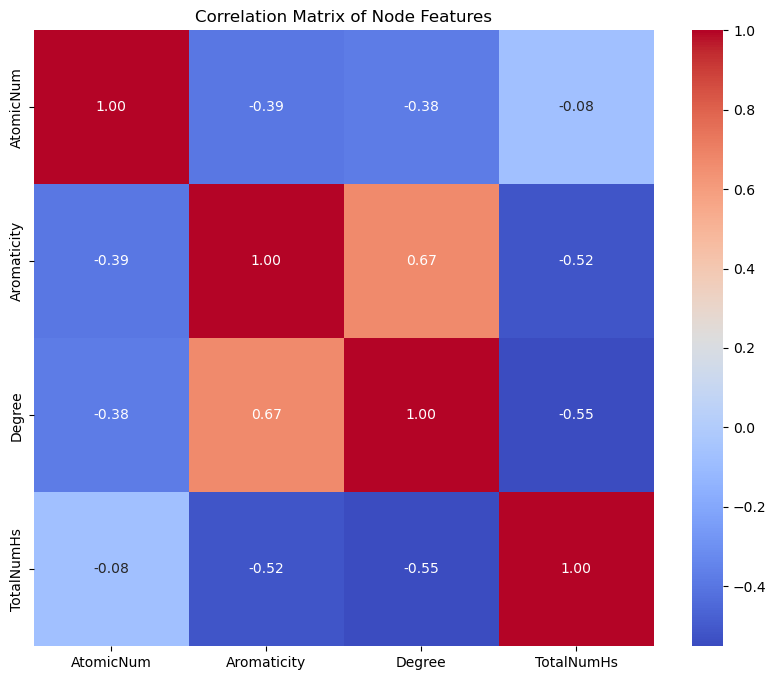

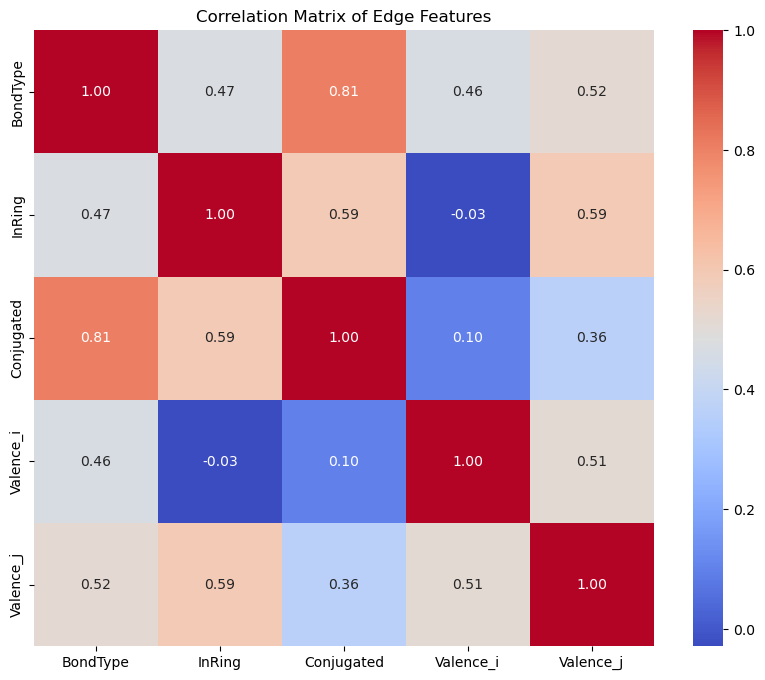

In [13]:
### node and edge information correlation
# data_list contains your PyG Data objects
node_feature_names = ['AtomicNum', 'Aromaticity', 'Degree','TotalNumHs'] #
mol_node_features = []
mol_node_features_extra = []

for data in data_list:
    x = data.x.cpu().numpy()  # shape [num_atoms, num_features]
    # Aggregate per molecule (mean)
    agg_features = x.mean(axis=0)
    mol_node_features.append(agg_features)

df_nodes = pd.DataFrame(mol_node_features, columns=node_feature_names)
corr_matrix = df_nodes.corr()


plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix of Node Features")
plt.show()

edge_feature_names = ['BondType','InRing', 'Conjugated' , 'Valence_i', 'Valence_j'] #,'Aromatic'

mol_edge_features = []
mol_edge_features_extra = []

for data in data_list:
    edge_attr = data.edge_attr.cpu().numpy()  # shape [num_edges, num_edge_features]
    if edge_attr.size == 0:
        # Molecule has no bonds, fill zeros
        agg_edge = np.zeros(len(edge_feature_names))
    else:
        agg_edge = edge_attr.mean(axis=0)
    mol_edge_features.append(agg_edge)

df_edges = pd.DataFrame(mol_edge_features, columns=edge_feature_names)

corr_matrix = df_edges.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix of Edge Features")
plt.show()

### Step 3 Split the dataset to training validation and testing

In [14]:
#split training val and testing sets as 8:1:1
from torch.utils.data import random_split

n = len(data_list)
train_size = int(0.8 * n)
val_size = int(0.1 * n)
test_size  = n - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_list, val_list, test_list = random_split(data_list, [train_size, val_size, test_size], generator=generator)

### Step 4 Constuction of GNN (3 layers)

In [15]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import NNConv, global_mean_pool, BatchNorm

class AtomicGNN(nn.Module):
    def __init__(self, in_dim, edge_dim, hidden1=64, hidden2=64, hidden3=64,
                 mlp_hidden=64, dropout=0.2):
        super().__init__()

        # NNConv layer 1
        self.nn1 = nn.Sequential(
            nn.Linear(edge_dim, in_dim * hidden1),
            nn.LeakyReLU(0.1)
        )
        self.conv1 = NNConv(in_dim, hidden1, self.nn1, aggr='add')
        self.bn1 = BatchNorm(hidden1)

        # NNConv layer 2
        self.nn2 = nn.Sequential(
            nn.Linear(edge_dim, hidden1 * hidden2),
            nn.LeakyReLU(0.1)
        )
        self.conv2 = NNConv(hidden1, hidden2, self.nn2, aggr='add')
        self.bn2 = BatchNorm(hidden2)

        # NNConv layer 3
        self.nn3 = nn.Sequential(
            nn.Linear(edge_dim, hidden2 * hidden3),
            nn.LeakyReLU(0.1)
        )
        self.conv3 = NNConv(hidden2, hidden3, self.nn3, aggr='add')
        self.bn3 = BatchNorm(hidden3)

        # Graph-level MLP
        self.fc1 = nn.Linear(hidden3, mlp_hidden)
        self.fc2 = nn.Linear(mlp_hidden, num_attr)

        # Dropout
        self.dropout = nn.Dropout(dropout)

        # Residual connection flag
        self.use_residual_1 = hidden1 == hidden2
        self.use_residual_2 = hidden2 == hidden3

    def forward(self, x, edge_index, edge_attr, batch):
        h1 = F.leaky_relu(self.bn1(self.conv1(x, edge_index, edge_attr)), negative_slope=0.1)
        h1 = self.dropout(h1)
        h2 = F.leaky_relu(self.bn2(self.conv2(h1, edge_index, edge_attr)), negative_slope=0.1)
        h2 = self.dropout(h2)

        if self.use_residual_1:
            h2 = h2 + h1  # residual

        h3 = F.leaky_relu(self.bn3(self.conv3(h2, edge_index, edge_attr)), negative_slope=0.1)
        h3 = self.dropout(h3)

        if self.use_residual_2:
            h3 = h3 + h2  # residual

        # Graph-level readout
        g = global_mean_pool(h3, batch)

        # MLP for regression
        g = self.dropout(F.leaky_relu(self.fc1(g), negative_slope=0.1))
        y_pred = self.fc2(g)

        return y_pred

### Step 5 Load data do training and validation with a changing learning rate

In [16]:
## load data
from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_list, batch_size=96, shuffle=True)
val_loader   = DataLoader(val_list, batch_size=96)
test_loader = DataLoader(test_list, batch_size=96)

In [17]:
## training 
from torch.optim.lr_scheduler import ReduceLROnPlateau
atomic_model = AtomicGNN(
    in_dim=data_list[0].x.shape[1],
    edge_dim=data_list[0].edge_attr.shape[1]
)
optimizer = torch.optim.Adam(atomic_model.parameters(), lr=1e-3)
## lr start at 1e-3, if 10 epoches no change, lr rate reduced by 10 times.
scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=10)

loss_fn = nn.MSELoss()

train_losses = []
val_losses = []
lr_history = []

max_epochs = 300
for epoch in range(max_epochs):
    atomic_model.train()
    train_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        y_pred = atomic_model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = loss_fn(y_pred, batch.y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    atomic_model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            y_pred = atomic_model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = loss_fn(y_pred, batch.y)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    
    lr_history.append(current_lr)

    scheduler.step(avg_val_loss)
    print(f"Epoch {epoch:03d} | Train={train_loss:.4f} | Val={val_loss:.4f} | LR={current_lr:.2e}")
    if current_lr < 1e-8:
        print("Learning rate below 1e-8. Stopping training.")
        break

Epoch 000 | Train=5.3056 | Val=30.7895 | LR=1.00e-03
Epoch 001 | Train=3.9003 | Val=8.2280 | LR=1.00e-03
Epoch 002 | Train=3.0713 | Val=3.5133 | LR=1.00e-03
Epoch 003 | Train=2.8610 | Val=1.3950 | LR=1.00e-03
Epoch 004 | Train=2.6519 | Val=0.5739 | LR=1.00e-03
Epoch 005 | Train=2.3719 | Val=0.3522 | LR=1.00e-03
Epoch 006 | Train=2.2300 | Val=0.3182 | LR=1.00e-03
Epoch 007 | Train=2.0442 | Val=0.3043 | LR=1.00e-03
Epoch 008 | Train=1.8622 | Val=0.2860 | LR=1.00e-03
Epoch 009 | Train=1.7549 | Val=0.2731 | LR=1.00e-03
Epoch 010 | Train=1.5458 | Val=0.2600 | LR=1.00e-03
Epoch 011 | Train=1.4377 | Val=0.2542 | LR=1.00e-03
Epoch 012 | Train=1.2701 | Val=0.2462 | LR=1.00e-03
Epoch 013 | Train=1.2324 | Val=0.2367 | LR=1.00e-03
Epoch 014 | Train=1.1514 | Val=0.2252 | LR=1.00e-03
Epoch 015 | Train=1.1194 | Val=0.2168 | LR=1.00e-03
Epoch 016 | Train=0.9952 | Val=0.1989 | LR=1.00e-03
Epoch 017 | Train=0.9868 | Val=0.1899 | LR=1.00e-03
Epoch 018 | Train=0.8895 | Val=0.1774 | LR=1.00e-03
Epoch 019 |

KeyboardInterrupt: 

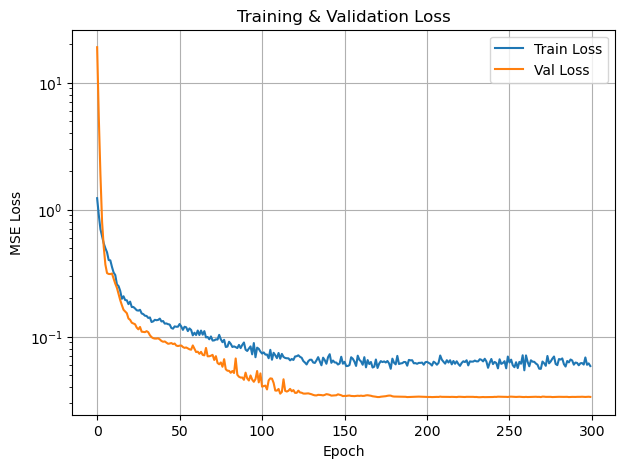

In [ ]:
## plot the loss for training and validation as a function of epoches
plt.figure(figsize=(7,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.yscale("log")
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

### Step 6 Evaluate the performance of our GNN

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def evaluate_and_plot(
        atomic_model, 
        loader, 
        id_list, 
        device="cpu",
        title="Set Performance",
        threshold_poor=0.18,
        threshold_good=0.01
        ):
    
    atomic_model.eval()

    y_true = []
    y_pred = []
    name_list = []
    id_list = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            pred = atomic_model(
                batch.x,
                batch.edge_index,
                batch.edge_attr,
                batch.batch
            )

            y_true.append(batch.y.cpu())
            y_pred.append(pred.cpu())
            name_list.append(batch.name)
            id_list.append(batch.id)

    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()

    name_list = [x for xs in name_list for x in xs]
    id_list = [x for xs in id_list for x in xs]
   
    y_true = y_true * y_stds + y_means
    y_pred = y_pred * y_stds + y_means


    r2 = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{title} Metrics:")
    print(f"   R²   = {r2:.4f}")
    print(f"   RMSE = {rmse:.4f}")
    print(f"   MAE  = {mae:.4f}")

#plot prediction vs real, only molecular feature 0 is plotted here.
    plt.figure(figsize=(6,6))
    plt.scatter(y_true[:,0], y_pred[:,0], alpha=0.7)

    low = min(y_true[:,0].min(), y_pred[:,0].min())
    high = max(y_true[:,0].max(), y_pred[:,0].max())
    plt.plot([low, high], [low, high], linestyle="--")

    plt.xlabel("Real y")
    plt.ylabel("Predicted y")
    plt.title(f"{title}\nR² = {r2:.4f}, RMSE = {rmse:.4f}, MAE = {mae:.4f}")
    plt.grid(True)
    plt.show()

    return y_true, y_pred, r2, rmse, mae, name_list, id_list

Training Set Metrics:
   R²   = 0.7129
   RMSE = 0.0311
   MAE  = 0.0568


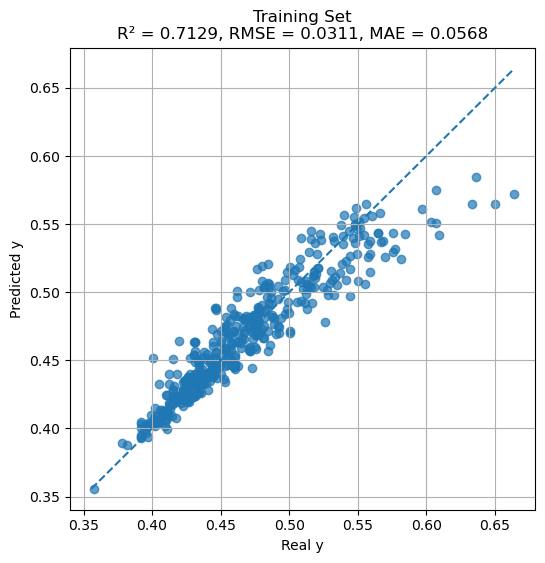

Validation Set Metrics:
   R²   = 0.6887
   RMSE = 0.0336
   MAE  = 0.0585


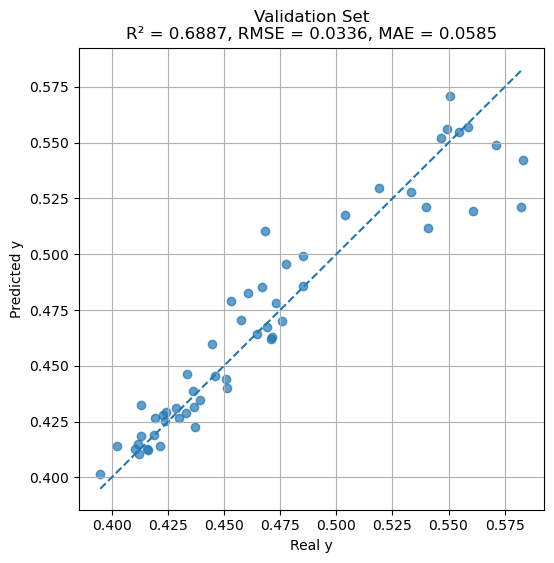

Test Set Metrics:
   R²   = 0.6311
   RMSE = 0.0533
   MAE  = 0.0741


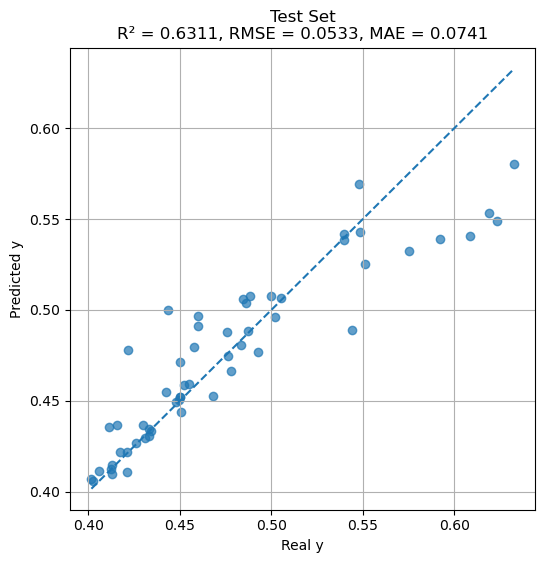

['5SQ', 'SCH', 'SMC', '2ML', 'ESC', '56A', 'LCK', 'ALV', 'TBG', 'B2H', '4CF', 'ORN', 'MBQ', 'AQG', 'THC', 'CLV', 'DAR', '7R6', 'MK8', 'DAB', 'KFP', 'LEN', 'TUK', 'API', 'PHL', 'DCY', 'AKZ', '4AR', 'SWG', 'DMH', 'THR', 'ECC', 'MTY', 'ARG', 'NYG', 'DM0', 'MCS', 'LYS', 'NLO', 'LVN', 'NH2', 'ILY', 'DMK', 'LP6', 'CYG', 'HLU', 'CME', 'BAL', '07O', 'JJL', 'BG1', 'FGL', 'TYO', 'KCR', 'CYJ', 'AR7', '1X6', '5ZA', 'IPG', 'NAL', 'TRX', '2MT', 'CFY', 'BB7', 'CWR', 'ASB', 'NA8', 'DTH', 'LYF', 'LGY', 'TY9', 'MPQ', 'KY7', 'MAN', 'ALN', 'WVL', 'TIS', 'RE0', 'MMT', 'AEI', 'DI7', 'CQ2', 'KST', 'PIA', 'CR7', 'TTS', 'T0I', 'NPH', 'SEB', 'WCR', '1OP', '1TY', '7R0', 'DAL', 'XPR', 'MED', 'HTR', 'GLZ', '1AC', 'CSH', 'CGA', 'RE3', 'SC2', 'HHK', 'OIM', 'C5C', 'B3Y', 'SCY', 'DYG', 'B3X', 'DSG', 'OCS', 'HIX', '3AH', 'BCX', 'HS8', 'HZP', 'LYN', 'NAG', 'LYZ', 'GMA', 'HAR', 'IZO', 'MMO', 'AHO', 'DDE', 'AGQ', 'DBU', 'P2Q', '02K', 'OHI', '0BN', 'YCM', 'FHL', 'GYS', 'EYG', '23P', 'XSN', 'HSV', 'GL3', 'TYQ', 'ZZJ', 'MGG'

array([[ 0.5431181 ,  0.01183316,  1.065614  , ...,  8.179872  ,
        -0.18885806,  2.5895762 ],
       [ 0.4372308 ,  0.01317367,  1.060985  , ...,  5.331953  ,
        -0.20392972,  1.9860399 ],
       [ 0.42179793,  0.01473892,  1.0610815 , ...,  4.719534  ,
        -0.20062204,  1.8879104 ],
       ...,
       [ 0.5565455 ,  0.01122347,  1.0716467 , ...,  8.921185  ,
        -0.21687526,  2.9025853 ],
       [ 0.4734969 ,  0.0159189 ,  1.0680571 , ...,  6.3945417 ,
        -0.21372777,  2.2116337 ],
       [ 0.45892364,  0.01493052,  1.0640955 , ...,  5.4433002 ,
        -0.17849429,  1.8151977 ]], shape=(442, 12), dtype=float32)

In [ ]:
id_list = df_polar['ncAA_ID'].tolist()

y_train_true, y_train_pred, r2, rmse, mae, train_name_list, train_id_list = evaluate_and_plot(atomic_model, train_loader,id_list, title="Training Set")

y_val_true, y_val_pred,   r2, rmse, mae, val_name_list, val_id_list= evaluate_and_plot(atomic_model, val_loader, id_list,  title="Validation Set")
 
y_test_true, y_test_pred,  r2, rmse, mae, test_name_list, test_id_list= evaluate_and_plot(atomic_model, test_loader,id_list,  title="Test Set")

print(train_id_list)
display(y_train_pred)

### Peptide Level SageGNN construction for the prediction of peptide properties made of predicted cannoncial amino acids that have been predicted

In [ ]:
import torch
import torch.nn as nn
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import SAGEConv, global_add_pool
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

Predict the amino acid (whether cannonical or noncannonical) properties for chosen features as an embedding matrix from the previous GNN. 

In [ ]:
canonical_smiles = {
    "A": "N[C@@H](C)C(=O)O",
    "R": "N[C@@H](CCCNC(N)=N)C(=O)O",
    "N": "N[C@@H](CC(=O)N)C(=O)O",
    "D": "N[C@@H](CC(=O)O)C(=O)O",
    "C": "N[C@@H](CS)C(=O)O",
    "E": "N[C@@H](CCC(=O)O)C(=O)O",
    "Q": "N[C@@H](CCC(=O)N)C(=O)O",
    "G": "NCC(=O)O",
    "H": "N[C@@H](Cc1c[nH]cn1)C(=O)O",
    "I": "N[C@@H](CC(C)C)C(=O)O",
    "L": "N[C@@H](CC(C)C)C(=O)O",
    "K": "N[C@@H](CCCCN)C(=O)O",
    "M": "N[C@@H](CCSC)C(=O)O",
    "F": "N[C@@H](Cc1ccccc1)C(=O)O",
    "P": "N1[C@@H](CCC1)C(=O)O",
    "S": "N[C@@H](CO)C(=O)O",
    "T": "N[C@@H](C(O)C)C(=O)O",
    "W": "N[C@@H](Cc1c[nH]c2ccccc12)C(=O)O",
    "Y": "N[C@@H](Cc1ccc(O)cc1)C(=O)O",
    "V": "N[C@@H](C(C)C)C(=O)O",
} # for the 20 cannonical amino acids

# Use insertion order
aa_order = list(canonical_smiles.keys())
print("aa_order:", aa_order)

# Build SMILES in the same order
canonical_smiles_list = [canonical_smiles[aa] for aa in aa_order]

canonical_graphs = [
    smiles_to_graph(smile_id, y=None, node_ft_dict=None, edge_ft_dict=None, device='cpu')
    for smile_id in canonical_smiles_list
]

from torch_geometric.data import Batch
device = "cpu"
batch = Batch.from_data_list(canonical_graphs).to(device)

atomic_model.eval()
with torch.no_grad():
    pred_cAAs = atomic_model(
        batch.x,
        batch.edge_index,
        batch.edge_attr,
        batch.batch
    )   # [number_of_amino_acids, num_properties]

aa_embedding_matrix = pred_cAAs  # rows aligned with aa_order
aa_to_idx = {aa: i for i, aa in enumerate(aa_order)}

aa_order: ['A', 'R', 'N', 'D', 'C', 'E', 'Q', 'G', 'H', 'I', 'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']


In [ ]:
aa_list = list(canonical_smiles)
aa_to_idx = {aa: i for i, aa in enumerate(aa_order)}

print(aa_to_idx)

{'A': 0, 'R': 1, 'N': 2, 'D': 3, 'C': 4, 'E': 5, 'Q': 6, 'G': 7, 'H': 8, 'I': 9, 'L': 10, 'K': 11, 'M': 12, 'F': 13, 'P': 14, 'S': 15, 'T': 16, 'W': 17, 'Y': 18, 'V': 19}


In [ ]:
# data structure, GNNs 
def seq_to_graph(seq, aa_to_idx, aa_embedding_matrix, device="cpu"):
    """
    Convert a peptide sequence to graph
      - nodes: residues, each with d-dim AA embedding matrix
      - edges: undirected chain edges between i and i+1
    """
    L = len(seq)

    # nodes
    x_list = []
    for aa in seq:
        if aa not in aa_to_idx:
            raise KeyError(f"Unknown amino acid in sequence: {aa}")
        idx = aa_to_idx[aa]
        x_list.append(aa_embedding_matrix[idx])

    # Stack into [L, d]
    x = torch.stack(x_list, dim=0).to(device)

    # Build undirected chain edges
    src = [] # source 
    dst = [] # destination
    for i in range(L - 1):
        src.append(i)
        dst.append(i + 1)
        src.append(i + 1)
        dst.append(i)

    if len(src) == 0:
        # single-residue peptide
        edge_index = torch.zeros((2, 0), dtype=torch.long, device=device)
    else:
        edge_index = torch.tensor([src, dst], dtype=torch.long, device=device)

    return x, edge_index

class MiniPepSAGE(nn.Module):
    """
    Residue-level GNN using GraphSAGE:
      - two SAGEConv layers
      - global mean pooling
      - small MLP head for AMP vs non-AMP
    """
    def __init__(self, in_dim, hidden_dim=64, dropout=0.2):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x, edge_index, batch):
        """
        x: [N_nodes, in_dim]
        edge_index: [2, E]
        batch: [N_nodes] assigning each node to a peptide-graph
        """
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        h = self.conv2(h, edge_index)
        h = F.relu(h)

        hg = global_mean_pool(h, batch)  # [n_graphs, hidden_dim]
        hg = self.dropout(hg)
        out = self.fc(hg)               # [n_graphs, 1]
        return out.view(-1)             # [n_graphs]

In [ ]:
# data manipulation
test_path = "data/Test_clean.csv"
train_path = "data/Train_clean.csv"

test_df = pd.read_csv(test_path)
train_df = pd.read_csv(train_path)

def build_dataset(df_slice, aa_to_idx, aa_embedding_matrix, device="cpu"):
    data_list = []
    for _, row in df_slice.iterrows():
        seq = row["Sequence"]
        y_val = float(row["Label"])  # 0 = non-AMP, 1 = AMP

        x, edge_index = seq_to_graph(
            seq,
            aa_to_idx=aa_to_idx,
            aa_embedding_matrix=aa_embedding_matrix,
            device=device
        )

        data = Data(
            x=x,
            edge_index=edge_index,
            y=torch.tensor([y_val], dtype=torch.float)
        )
        data_list.append(data)

    return data_list

device = "cuda" if torch.cuda.is_available() else "cpu" # choice does affect code speed

train_data = build_dataset(train_df, aa_to_idx, aa_embedding_matrix, device)
test_data  = build_dataset(test_df, aa_to_idx, aa_embedding_matrix, device)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader  = DataLoader(test_data,  batch_size=128, shuffle=False)

/var/folders/s0/t_79kbkd35sgg4vbs8rzbsmw0000gn/T/ipykernel_2651/3726989186.py:35: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
/var/folders/s0/t_79kbkd35sgg4vbs8rzbsmw0000gn/T/ipykernel_2651/3726989186.py:36: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader  = DataLoader(test_data,  batch_size=128, shuffle=False)


In [ ]:
# training and evaluation
in_dim = train_data[0].x.size(1)
pep_model = MiniPepSAGE(in_dim=in_dim, hidden_dim=64, dropout=0.2).to(device)

optimizer = torch.optim.Adam(pep_model.parameters(), lr=1e-3)
loss_fn = nn.BCEWithLogitsLoss()

num_epochs   = 300
train_losses = []
val_losses   = []
val_aucs     = []

for epoch in range(1, num_epochs + 1):
    # train
    pep_model.train()
    total_loss = 0.0

    for batch in train_loader:
        batch = batch.to(device)

        logits = pep_model(batch.x, batch.edge_index, batch.batch)
        loss   = loss_fn(logits, batch.y.view(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item()) * batch.num_graphs

    avg_train_loss = total_loss / len(train_data)
    train_losses.append(avg_train_loss)

    # validate
    pep_model.eval()
    running_val_loss = 0.0
    n_val_batches    = 0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            logits = pep_model(batch.x, batch.edge_index, batch.batch)
            probs  = torch.sigmoid(logits)
            loss = loss_fn(logits, batch.y.view(-1))
            running_val_loss += loss.item()
            n_val_batches    += 1
            all_probs.append(probs.cpu())
            all_labels.append(batch.y.view(-1).cpu())
    avg_val_loss = running_val_loss / max(n_val_batches, 1)
    val_losses.append(avg_val_loss)
    y_true = np.concatenate([t.numpy() for t in all_labels])
    y_pred = np.concatenate([p.numpy() for p in all_probs])
    auc    = roc_auc_score(y_true, y_pred)
    val_aucs.append(auc)
    print(
        f"Epoch {epoch:03d} | "
        f"train loss = {avg_train_loss:.4f} | "
        f"val loss = {avg_val_loss:.4f} | "
        f"val AUC = {auc:.3f}"
    )

Epoch 001 | train loss = 0.6867 | val loss = 0.6835 | val AUC = 0.609
Epoch 002 | train loss = 0.6861 | val loss = 0.6823 | val AUC = 0.609
Epoch 003 | train loss = 0.6826 | val loss = 0.6688 | val AUC = 0.640
Epoch 004 | train loss = 0.6593 | val loss = 0.6584 | val AUC = 0.719
Epoch 005 | train loss = 0.6378 | val loss = 0.6227 | val AUC = 0.726
Epoch 006 | train loss = 0.6174 | val loss = 0.6084 | val AUC = 0.737
Epoch 007 | train loss = 0.6060 | val loss = 0.5861 | val AUC = 0.763
Epoch 008 | train loss = 0.5982 | val loss = 0.5932 | val AUC = 0.774
Epoch 009 | train loss = 0.5867 | val loss = 0.5733 | val AUC = 0.779
Epoch 010 | train loss = 0.5753 | val loss = 0.5588 | val AUC = 0.786
Epoch 011 | train loss = 0.5688 | val loss = 0.5531 | val AUC = 0.797
Epoch 012 | train loss = 0.5621 | val loss = 0.5456 | val AUC = 0.802
Epoch 013 | train loss = 0.5524 | val loss = 0.5496 | val AUC = 0.808
Epoch 014 | train loss = 0.5480 | val loss = 0.5358 | val AUC = 0.816
Epoch 015 | train lo

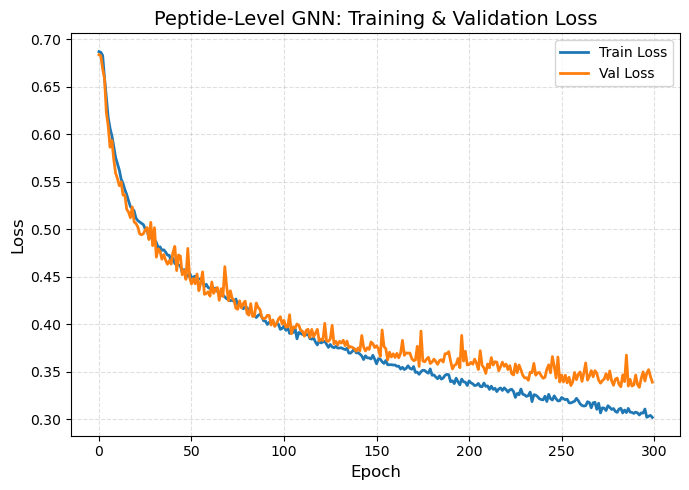

In [ ]:
# BCEWithLogitsLoss (classification), keep linear scale

plt.figure(figsize=(7,5))

plt.plot(train_losses, label="Train Loss", linewidth=2)
plt.plot(val_losses, label="Val Loss", linewidth=2)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Peptide-Level GNN: Training & Validation Loss", fontsize=14)

plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Confusion matrix:
 [[1717  402]
 [ 269 2398]]


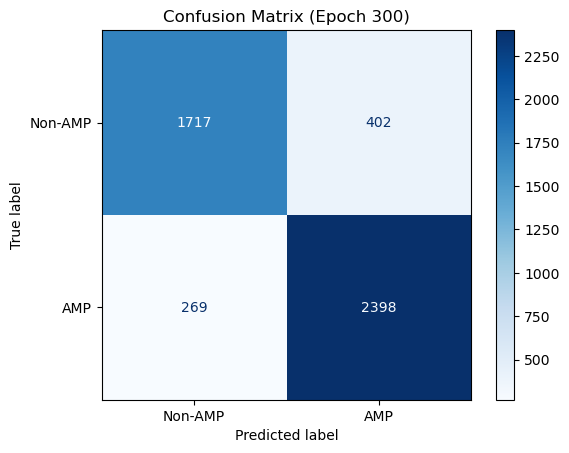

,Sequence,TrueLabel,PredProb,PredLabel
0,AVDQDLGPEVPPENVLGALL,0,0.215517,0
1,KKKKVVAATYVLE,1,0.992112,1
2,MAYTSLLSFSVCLLVLFHGCCA,0,0.010317,0
3,ILPWKWPWWPWWKKPWRR,1,0.999813,1
4,GLFDIIKNIFSGL,1,0.989622,1
5,GKKLFVNVLDKIRCKVAGGC,1,0.962437,1
6,MKVLAVSLAFLLIAGLISTSLAENDEGGEKELVRVRRGGYYCPFRQ...,1,0.980005,1
7,INWKKIASIGKEVLKAI,1,0.988352,1
8,AGEGLNSQFWSLAAPQRF,0,0.029729,0
9,SFKRLKGFAKKLWNSKLARKIRTKGLKYVKNFAKDMLSEGEEAPPA...,1,0.920654,1


In [ ]:
# 1) hard predictions
y_pred_label = (y_pred >= 0.5).astype(int)

# 2) confusion matrix
cm = confusion_matrix(y_true, y_pred_label)
print("Confusion matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-AMP", "AMP"])
fig, ax = plt.subplots()
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix (Epoch {epoch})")
plt.show()

# 3) inspect some predictions
import pandas as pd
n_show = 10
idx = np.random.choice(len(y_true), size=min(n_show, len(y_true)), replace=False)

df_view = pd.DataFrame({
    "Sequence": test_df["Sequence"].iloc[idx].values,
    "TrueLabel": y_true[idx].astype(int),
    "PredProb": y_pred[idx],
    "PredLabel": y_pred_label[idx],
})

display(df_view)

### Predicting Bioengineered Peptide's AMP activity

We now have two GNN's, one to predict properties of any amino acid, and another to determine if the peptide containing said amino acids will be AMP or non-AMP. We will now predict if said peptide will be AMP or non-AMP.

In [ ]:
import torch
from torch_geometric.data import Data, Batch

NCAA_TOKEN = "X"
aa_order = list(canonical_smiles.keys())
aa_to_idx = {aa: i for i, aa in enumerate(aa_order)}

def embed_smiles_with_atomic_nnconv(smiles, atomic_model, device="cpu"):
    g = smiles_to_graph(smiles, y=None, node_ft_dict=None, edge_ft_dict=None, device=device)
    b = Batch.from_data_list([g]).to(device)
    atomic_model.eval()
    with torch.no_grad():
        out = atomic_model(b.x, b.edge_index, b.edge_attr, b.batch)
    if out.dim() == 2:
        return out[0]
    if out.dim() == 1:
        return out
    raise ValueError(out.shape)

def build_canonical_embedding_matrix(atomic_model, device="cpu"):
    graphs = [
        smiles_to_graph(canonical_smiles[aa], y=None, node_ft_dict=None, edge_ft_dict=None, device=device)
        for aa in aa_order
    ]
    b = Batch.from_data_list(graphs).to(device)
    atomic_model.eval()
    with torch.no_grad():
        E = atomic_model(b.x, b.edge_index, b.edge_attr, b.batch)
    if E.dim() != 2 or E.size(0) != len(aa_order):
        raise ValueError(E.shape)
    return E

def seq_to_chain_graph_features(seq, aa_embedding_matrix, ncaa_embedding, device="cpu", ncaa_token=NCAA_TOKEN):
    x_list = []
    for ch in seq:
        if ch == ncaa_token:
            x_list.append(ncaa_embedding)
        else:
            x_list.append(aa_embedding_matrix[aa_to_idx[ch]])
    x = torch.stack(x_list, dim=0).to(device)
    L = x.size(0)
    if L < 2:
        edge_index = torch.empty((2, 0), dtype=torch.long, device=device)
        return x, edge_index
    src = torch.arange(0, L - 1, device=device)
    dst = torch.arange(1, L, device=device)
    edge_index = torch.stack([torch.cat([src, dst]), torch.cat([dst, src])], dim=0)
    return x, edge_index

def predict_amp_for_peptide_with_ncaa(
    peptide_seq,
    ncaa_smiles,
    atomic_model,
    pep_model,
    device="cpu",
    threshold=0.5,
    ncaa_token=NCAA_TOKEN
):
    atomic_model = atomic_model.to(device)
    pep_model = pep_model.to(device)

    aa_embedding_matrix = build_canonical_embedding_matrix(atomic_model, device=device)
    ncaa_embedding = embed_smiles_with_atomic_nnconv(ncaa_smiles, atomic_model, device=device)

    x, edge_index = seq_to_chain_graph_features(
        peptide_seq,
        aa_embedding_matrix,
        ncaa_embedding,
        device=device,
        ncaa_token=ncaa_token
    )

    data = Data(x=x, edge_index=edge_index)
    b = Batch.from_data_list([data]).to(device)

    pep_model.eval()
    with torch.no_grad():
        logits = pep_model(b.x, b.edge_index, b.batch)
        prob = torch.sigmoid(logits).item()

    return prob, int(prob >= threshold)

# example prediction

peptide_seq = "ACDXXFGK"
ncaa_smiles = "NC1(CCCCC1)C(O)=O"

prob, pred = predict_amp_for_peptide_with_ncaa(
    peptide_seq,
    ncaa_smiles,
    atomic_model,
    pep_model,
    device=device,
    threshold=0.5,
    ncaa_token=NCAA_TOKEN
)

print(f"AMP probability = {prob:.4f} | predicted class = {pred}")

AMP probability = 0.6108 | predicted class = 1
